In [1]:
import streamlit as st
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Set the page to be wide for a better chart view
st.set_page_config(layout="wide")
st.title("📈 Trading Simulator: Human vs. SMA Bot")

# 1. Generate Fake Stock Data (for the simulation)
np.random.seed(42)
days = 50
price_path = np.cumsum(np.random.randn(days) * 2) + 100 # Random walk
data = {
    'Date': pd.date_range(start='2026-01-01', periods=days),
    'Open': price_path + np.random.randn(days),
    'High': price_path + np.random.rand(days) * 3,
    'Low': price_path - np.random.rand(days) * 3,
    'Close': price_path + np.random.randn(days)
}
df = pd.DataFrame(data)

# 2. Calculate the SMA (What your bot looks at)
# Rolling average over the last 10 periods
df['SMA_10'] = df['Close'].rolling(window=10).mean()

# 3. Create the Interactive Plotly Chart
fig = go.Figure()

# Add the Candlesticks
fig.add_trace(go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    name='Market Price'
))

# Add the Bot's SMA Line
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['SMA_10'],
    mode='lines',
    line=dict(color='blue', width=2),
    name='Bot SMA (10-day)'
))

# Clean up the layout
fig.update_layout(
    xaxis_rangeslider_visible=False, # Hides the bulky slider at the bottom
    template='plotly_dark',          # Cool dark mode theme
    height=600,
    margin=dict(l=0, r=0, t=30, b=0)
)

# 4. Render everything in Streamlit
st.plotly_chart(fig, use_container_width=True)

# Add some interactive layout elements below the chart
col1, col2, col3 = st.columns(3)
with col1:
    st.button("🟢 BUY (Fight FOMO)", use_container_width=True)
with col2:
    st.button("🔴 SELL (Don't Panic)", use_container_width=True)
with col3:
    st.metric(label="Your Portfolio Balance", value="$10,000.00")

2026-02-28 21:31:52.119 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:31:52.123 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:31:53.059 
  command:

    streamlit run C:\Users\Hp\miniconda3\envs\PYCHARM\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-02-28 21:31:53.060 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:31:53.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:31:53.133 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, us

In [2]:
import streamlit as st
import plotly.graph_objects as go
import random
import math

# --- 1. INITIALIZE GAME STATE ---
# We use session_state so the web app remembers data between clicks
if 'initialized' not in st.session_state:
    st.session_state.initialized = True
    st.session_state.tick = 0
    st.session_state.price = 100.0
    st.session_state.price_history = [100.0] * 30
    st.session_state.sma_history = [100.0] * 30

    # Portfolios
    st.session_state.user_cash = 1000.0
    st.session_state.user_shares = 0
    st.session_state.bot_cash = 1000.0
    st.session_state.bot_shares = 0

    # Constants from your code
    st.session_state.trade_fee = 1.00
    st.session_state.mu = 0.005
    st.session_state.sigma = 0.04
    st.session_state.dt = 1.0

# --- 2. GAME LOGIC FUNCTIONS ---
def advance_market():
    # Geometric Brownian Motion (from your original code)
    Z = random.gauss(0, 1)
    drift = (st.session_state.mu - (st.session_state.sigma ** 2) / 2) * st.session_state.dt
    shock = st.session_state.sigma * math.sqrt(st.session_state.dt) * Z
    st.session_state.price = st.session_state.price * math.exp(drift + shock)

    if st.session_state.price < 1.0:
        st.session_state.price = 1.0

    # Update Histories
    st.session_state.price_history.append(st.session_state.price)
    if len(st.session_state.price_history) > 50: st.session_state.price_history.pop(0)

    # Bot SMA Logic (5-period)
    current_sma = sum(st.session_state.price_history[-5:]) / 5
    st.session_state.sma_history.append(current_sma)
    if len(st.session_state.sma_history) > 50: st.session_state.sma_history.pop(0)

    # Bot Trading Logic
    total_buy_cost = st.session_state.price + st.session_state.trade_fee
    if st.session_state.price > current_sma and st.session_state.bot_cash >= total_buy_cost:
        st.session_state.bot_cash -= total_buy_cost
        st.session_state.bot_shares += 1
    elif st.session_state.price < current_sma and st.session_state.bot_shares > 0:
        st.session_state.bot_cash += (st.session_state.price - st.session_state.trade_fee)
        st.session_state.bot_shares -= 1

    st.session_state.tick += 1

def human_buy():
    total_cost = st.session_state.price + st.session_state.trade_fee
    if st.session_state.user_cash >= total_cost:
        # Check for FOMO (Buying when price is > 3% above SMA)
        current_sma = st.session_state.sma_history[-1]
        if st.session_state.price > current_sma * 1.03:
            st.toast("🚀 ANTIGRAVITY ENGAGED! You FOMO bought the top!", icon="⚠️")

        st.session_state.user_cash -= total_cost
        st.session_state.user_shares += 1
    advance_market()

def human_sell():
    if st.session_state.user_shares > 0:
        # Check for Panic Selling (Selling when price is < 3% below SMA)
        current_sma = st.session_state.sma_history[-1]
        if st.session_state.price < current_sma * 0.97:
            st.toast("📉 GRAVITY CRASH! You panic sold the bottom!", icon="💥")

        st.session_state.user_cash += (st.session_state.price - st.session_state.trade_fee)
        st.session_state.user_shares -= 1
    advance_market()

def wait():
    advance_market()

# --- 3. UI DASHBOARD ---
st.set_page_config(layout="wide", page_title="Bot vs Brain")
st.title("🧠 Bot vs. Brain: The Quant Challenge")

# Portfolio Values
user_val = st.session_state.user_cash + (st.session_state.user_shares * st.session_state.price)
bot_val = st.session_state.bot_cash + (st.session_state.bot_shares * st.session_state.price)

# Scoreboard
col1, col2, col3 = st.columns(3)
col1.metric("👤 Human Portfolio", f"₹{user_val:.2f}", f"Cash: ₹{st.session_state.user_cash:.0f} | Shares: {st.session_state.user_shares}")
col2.metric("📈 Current Price", f"₹{st.session_state.price:.2f}", f"Tick: {st.session_state.tick}")
col3.metric("🤖 Bot Portfolio", f"₹{bot_val:.2f}", f"Cash: ₹{st.session_state.bot_cash:.0f} | Shares: {st.session_state.bot_shares}")

# Draw Plotly Chart
fig = go.Figure()
fig.add_trace(go.Scatter(y=st.session_state.price_history, mode='lines', name='Price', line=dict(color='#00ff00', width=3)))
fig.add_trace(go.Scatter(y=st.session_state.sma_history, mode='lines', name='Bot SMA (5)', line=dict(color='#ff9900', dash='dash', width=2)))

fig.update_layout(
    template='plotly_dark',
    height=450,
    margin=dict(l=0, r=0, t=30, b=0),
    xaxis_title="Time",
    yaxis_title="Price (₹)"
)
st.plotly_chart(fig, use_container_width=True)

# Controls
st.markdown("### Trading Terminal (Fee: ₹1.00/trade)")
c1, c2, c3 = st.columns(3)
with c1:
    st.button("🟢 BUY", on_click=human_buy, use_container_width=True)
with c2:
    st.button("🔴 SELL", on_click=human_sell, use_container_width=True)
with c3:
    st.button("⏳ WAIT (Next Tick)", on_click=wait, use_container_width=True)

2026-02-28 21:32:00.337 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32:00.338 Session state does not function when running a script without `streamlit run`
2026-02-28 21:32:00.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32:00.340 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32:00.341 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32:00.342 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32:00.342 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32:00.343 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-28 21:32

In [8]:
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.workbook.defined_name import DefinedName
from openpyxl.formatting.rule import CellIsRule, FormulaRule
from openpyxl.chart import BarChart, DoughnutChart, Reference
from openpyxl.utils import get_column_letter

def create_mba_simulator():
    wb = Workbook()

    # 1. Workbook Settings
    wb.iso_dates = True

    # Custom Number Formats
    INR_FORMAT = '[$₹-en-IN]##,##,##0'
    PCT_FORMAT = '0.0%'
    LAKH_FORMAT = '#,##0.0" L"'

    # Reusable Styles
    font_default = Font(name='Arial', size=10)
    font_bold = Font(name='Arial', size=10, bold=True)
    font_white_bold = Font(name='Arial', size=10, bold=True, color='FFFFFF')
    font_header = Font(name='Arial', size=14, bold=True, color='FFFFFF')

    align_center = Alignment(horizontal='center', vertical='center', wrap_text=True)
    align_left = Alignment(horizontal='left', vertical='center', wrap_text=True)
    align_right = Alignment(horizontal='right', vertical='center')

    border_thin = Border(left=Side(style='thin'), right=Side(style='thin'),
                         top=Side(style='thin'), bottom=Side(style='thin'))

    fill_navy = PatternFill(start_color='1A2744', end_color='1A2744', fill_type='solid')
    fill_lavender = PatternFill(start_color='E8EAF6', end_color='E8EAF6', fill_type='solid')
    fill_light_grey = PatternFill(start_color='F8F8F8', end_color='F8F8F8', fill_type='solid')
    fill_med_grey = PatternFill(start_color='F0F0F0', end_color='F0F0F0', fill_type='solid')
    fill_yellow = PatternFill(start_color='FFFDE7', end_color='FFFDE7', fill_type='solid')
    fill_light_blue = PatternFill(start_color='E3F2FD', end_color='E3F2FD', fill_type='solid')
    fill_med_navy = PatternFill(start_color='2C3E7A', end_color='2C3E7A', fill_type='solid')

    sheet_names = ['Inputs', 'Single Scenario', 'Monte Carlo Engine', 'Results Dashboard', 'Scenario Profiles']
    tabs = []

    # Initialize sheets
    default_ws = wb.active
    default_ws.title = sheet_names[0]
    tabs.append(default_ws)
    for name in sheet_names[1:]:
        tabs.append(wb.create_sheet(title=name))

    # Set Tab Colors
    tab_colors = ['0000FF', '008000', 'FFA500', '800080', 'FF0000']
    for ws, color in zip(tabs, tab_colors):
        ws.sheet_properties.tabColor = color

    # --- HELPER FUNCTIONS ---
    def apply_default_font(ws):
        for row in ws.iter_rows():
            for cell in row:
                if cell.font.name is None or cell.font.name == 'Calibri':
                    cell.font = font_default

    def build_nav_bar(ws):
        ws.row_dimensions[1].height = 20
        # Simulating a merged nav bar across columns A to K
        nav_elements = [
            ("Navigate → ", None),
            ("[Inputs]", "Inputs"), (" | ", None),
            ("[Single Scenario]", "Single Scenario"), (" | ", None),
            ("[Monte Carlo Engine]", "Monte Carlo Engine"), (" | ", None),
            ("[Dashboard]", "Results Dashboard"), (" | ", None),
            ("[Scenario Profiles]", "Scenario Profiles")
        ]

        for col_idx, (text, link) in enumerate(nav_elements, start=1):
            cell = ws.cell(row=1, column=col_idx)
            cell.value = text
            cell.fill = PatternFill(start_color='37474F', end_color='37474F', fill_type='solid')
            cell.font = Font(name='Arial', size=9, color='FFFFFF', underline='single' if link else 'none')
            cell.alignment = Alignment(horizontal='center', vertical='center')
            if link:
                cell.hyperlink = f"#'{link}'!A1"

        # Fill rest of row 1 to look like a solid bar
        for col_idx in range(len(nav_elements) + 1, 15):
            cell = ws.cell(row=1, column=col_idx)
            cell.fill = PatternFill(start_color='37474F', end_color='37474F', fill_type='solid')

        ws.freeze_panes = 'A3'

    # =========================================================================
    # SHEET 1: INPUTS
    # =========================================================================
    ws = tabs[0]

    ws.merge_cells('A2:D2')
    ws['A2'] = "MBA LOAN DECISION SIMULATOR — INPUT PARAMETERS"
    ws['A2'].fill = fill_navy
    ws['A2'].font = font_header
    ws['A2'].alignment = align_center
    ws.row_dimensions[2].height = 40

    ws.merge_cells('A3:D3')
    ws['A3'] = "Change the yellow cells below to model your own situation. All other sheets update automatically."
    ws['A3'].fill = fill_lavender
    ws['A3'].font = Font(name='Arial', size=9, italic=True, color='555555')
    ws['A3'].alignment = align_center
    ws.row_dimensions[3].height = 25

    headers = ["Parameter", "Value", "Unit", "Notes"]
    for col, text in enumerate(headers, start=1):
        cell = ws.cell(row=4, column=col, value=text)
        cell.font = font_bold
        cell.fill = fill_med_grey
        cell.border = border_thin
        cell.alignment = align_center

    ws.column_dimensions['A'].width = 40
    ws.column_dimensions['B'].width = 18
    ws.column_dimensions['C'].width = 12
    ws.column_dimensions['D'].width = 50

    input_data = [
        ("PERSONAL DETAILS", None, None, None, True),
        ("Current Age", 22, "Years", "Age of the student at the start of simulation", False),
        ("Pre-MBA Monthly Salary", 40000, "₹ / month", "Current take-home salary before doing MBA", False),
        ("EDUCATION LOAN DETAILS", None, None, None, True),
        ("MBA Loan Amount", 2000000, "₹", "Total loan taken to fund MBA (₹20 Lakhs)", False),
        ("Loan Interest Rate (Annual)", 0.09, "% per year", "Annual interest rate on education loan (9%)", False),
        ("Loan Repayment Tenure", 7, "Years", "Number of years to repay the loan after MBA", False),
        ("MBA Duration", 2, "Years", "How long the MBA program takes (no income during this time)", False),
        ("MBA CAREER ASSUMPTIONS", None, None, None, True),
        ("Post-MBA Salary Hike — Minimum", 0.40, "% of current salary", "Lowest expected salary increase after MBA (40%)", False),
        ("Post-MBA Salary Hike — Maximum", 0.80, "% of current salary", "Highest expected salary increase after MBA (80%)", False),
        ("Annual Salary Growth Rate — Mean", 0.08, "% per year", "Expected average annual salary increment (8%)", False),
        ("Annual Salary Growth Rate — Std Deviation", 0.03, "—", "Uncertainty in salary growth (higher = more variable career)", False),
        ("INVESTMENT & MARKET ASSUMPTIONS", None, None, None, True),
        ("Equity Investment Return — Mean (Annual)", 0.12, "% per year", "Expected annual return from equity mutual funds (12%)", False),
        ("Equity Investment Return — Std Deviation", 0.05, "—", "Volatility of market returns (higher = riskier market)", False),
        ("Annual Inflation Rate — Mean", 0.05, "% per year", "Expected average inflation rate (5%)", False),
        ("Annual Inflation Rate — Std Deviation", 0.015, "—", "Uncertainty in inflation rate", False),
        ("SIMULATION SETTINGS", None, None, None, True),
        ("Analysis Horizon", 18, "Years", "Total years simulated from today (reaches age 40)", False),
        ("Living Expense Rate", 0.50, "% of salary", "Fraction of pre-MBA salary used for living costs", False),
        ("Savings Investment Rate (Path B)", 0.30, "% of salary", "Fraction of salary Path B person invests each year beyond EMI", False)
    ]

    row_idx = 5
    named_ranges_dict = {}

    for row_data in input_data:
        ws.row_dimensions[row_idx].height = 20
        is_header = row_data[4]
        if is_header:
            ws.merge_cells(start_row=row_idx, start_column=1, end_row=row_idx, end_column=4)
            cell = ws.cell(row=row_idx, column=1, value=row_data[0])
            cell.fill = fill_navy
            cell.font = font_white_bold
            cell.alignment = align_center
            # Apply borders to merged cells
            for c in range(1, 5):
                ws.cell(row=row_idx, column=c).border = border_thin
        else:
            c1 = ws.cell(row=row_idx, column=1, value=row_data[0])
            c1.fill = fill_light_grey
            c1.font = font_bold
            c1.border = border_thin
            c1.alignment = align_left

            c2 = ws.cell(row=row_idx, column=2, value=row_data[1])
            c2.fill = fill_yellow
            c2.border = border_thin
            c2.alignment = align_right
            if "%" in row_data[2] or row_data[0].endswith("Std Deviation"):
                c2.number_format = PCT_FORMAT
            elif "₹" in row_data[2]:
                c2.number_format = INR_FORMAT

            # Map for named ranges
            var_name = row_data[0].split("—")[0].strip().replace(" ", "").replace("(Annual)", "").replace("Post-MBA", "").replace("Annual", "").replace("Rate", "")
            # Hardcode exact named range mapping based on spec
            nr_map = {
                "Current Age": "currentAge", "Pre-MBA Monthly Salary": "preMBASalary",
                "MBA Loan Amount": "loanAmount", "Loan Interest Rate": "loanRate",
                "Loan Repayment Tenure": "loanTenure", "MBA Duration": "mbaDuration",
                "Salary Hike  Minimum": "minHike", "Salary Hike  Maximum": "maxHike",
                "Salary Growth  Mean": "meanSalaryGrowth", "Salary Growth  Std Deviation": "sdSalaryGrowth",
                "Equity Investment Return  Mean": "meanReturn", "Equity Investment Return  Std Deviation": "sdReturn",
                "Inflation  Mean": "meanInflation", "Inflation  Std Deviation": "sdInflation",
                "Analysis Horizon": "horizon", "Living Expense": "livingExpenseRate",
                "Savings Investment (Path B)": "savingsRate"
            }
            clean_key = row_data[0].replace("—", "").replace("  ", " ").strip()
            for k, v in nr_map.items():
                if k in clean_key:
                    named_ranges_dict[v] = f"Inputs!$B${row_idx}"

            c3 = ws.cell(row=row_idx, column=3, value=row_data[2])
            c3.fill = fill_light_grey
            c3.border = border_thin
            c3.alignment = align_center

            c4 = ws.cell(row=row_idx, column=4, value=row_data[3])
            c4.font = Font(name='Arial', size=9, italic=True, color='555555')
            c4.border = border_thin
            c4.alignment = align_left

        row_idx += 1

    # Create Named Ranges
    for name, ref in named_ranges_dict.items():
        wb.defined_names.add(DefinedName(name=name, attr_text=ref))

    # Calculated Constants
    row_idx += 1
    ws.merge_cells(start_row=row_idx, start_column=1, end_row=row_idx, end_column=4)
    cell = ws.cell(row=row_idx, column=1, value="CALCULATED CONSTANTS")
    cell.fill = fill_navy
    cell.font = font_white_bold
    cell.alignment = align_center
    row_idx += 1

    calc_data = [
        ("Monthly EMI (Path A loan repayment)", "=PMT(loanRate/12, loanTenure*12, loanAmount)*-1", "₹ / month", "Fixed monthly repayment amount during loan tenure"),
        ("Annual EMI (total yearly repayment)", "=B29*12", "₹ / year", ""), # B29 is row_idx
        ("Post-MBA Starting Salary (at mean hike)", "=preMBASalary*12*(1+((minHike+maxHike)/2))", "₹ / year", "Annual salary immediately after MBA at average hike"),
        ("Target Age at End of Simulation", "=currentAge+horizon", "Years", "")
    ]

    for i, data in enumerate(calc_data):
        c1 = ws.cell(row=row_idx+i, column=1, value=data[0])
        c1.fill = fill_light_grey; c1.font = font_bold; c1.border = border_thin

        c2 = ws.cell(row=row_idx+i, column=2, value=data[1])
        if i == 1: c2.value = f"=B{row_idx}*12" # Fix dynamic reference
        c2.fill = fill_light_blue; c2.border = border_thin
        if i < 3: c2.number_format = INR_FORMAT

        c3 = ws.cell(row=row_idx+i, column=3, value=data[2])
        c3.fill = fill_light_grey; c3.border = border_thin; c3.alignment = align_center

        c4 = ws.cell(row=row_idx+i, column=4, value=data[3])
        c4.font = Font(name='Arial', size=9, italic=True, color='555555'); c4.border = border_thin

    apply_default_font(ws)
    build_nav_bar(ws)

    # Sheet protection for Inputs A column
    ws.protection.sheet = True
    for row in ws.iter_rows(min_row=5, max_row=row_idx+3):
        row[1].protection = openpyxl.styles.Protection(locked=False) # Unlock B column

    # =========================================================================
    # SHEET 2: SINGLE SCENARIO
    # =========================================================================
    ws = tabs[1]

    ws.merge_cells('A2:L2')
    ws['A2'] = "SINGLE SCENARIO — DETERMINISTIC WALKTHROUGH (Using Mean Values, No Randomness)"
    ws['A2'].fill = fill_navy; ws['A2'].font = Font(name='Arial', size=13, bold=True, color='FFFFFF'); ws['A2'].alignment = align_center
    ws.row_dimensions[2].height = 40

    ws.merge_cells('A3:L3')
    ws['A3'] = "This shows one sample life path using average/expected values. The Monte Carlo sheet runs 1,000 random versions of this."
    ws['A3'].fill = fill_lavender; ws['A3'].font = Font(name='Arial', size=9, italic=True); ws['A3'].alignment = align_center

    headers = ["Year", "Age", "PATH A — Annual Salary (₹)", "PATH A — Annual EMI Paid (₹)",
               "PATH A — Living Expenses (₹)", "PATH A — Annual Savings (₹)", "PATH A — Cumulative Net Worth (₹)",
               "PATH B — Annual Salary (₹)", "PATH B — Annual SIP Investment (₹)", "PATH B — Extra Annual Savings (₹)",
               "PATH B — Cumulative Net Worth (₹)", "NET WORTH DIFFERENCE (A minus B) (₹)"]

    col_widths = [8, 8, 18, 18, 18, 18, 20, 18, 20, 20, 20, 22]
    for i, w in enumerate(col_widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    for col, text in enumerate(headers, start=1):
        cell = ws.cell(row=4, column=col, value=text)
        cell.fill = fill_med_navy; cell.font = font_white_bold; cell.border = border_thin; cell.alignment = align_center
        ws.row_dimensions[4].height = 35

    # Formulas for Year 0 (Row 5)
    ws['A5'] = 0; ws['B5'] = "=currentAge"; ws['C5'] = 0; ws['D5'] = 0
    ws['E5'] = "=preMBASalary*12*livingExpenseRate"
    ws['F5'] = "=C5-D5-E5"; ws['G5'] = 0
    ws['H5'] = "=preMBASalary*12"
    ws['I5'] = "=Inputs!B29"
    ws['J5'] = "=H5*savingsRate"
    ws['K5'] = 0; ws['L5'] = "=G5-K5"

    # Year 1 (Row 6)
    ws['A6'] = 1; ws['B6'] = "=B5+1"; ws['C6'] = 0; ws['D6'] = 0
    ws['E6'] = "=E5*(1+meanInflation)"; ws['F6'] = "=C6-D6-E6"
    ws['G6'] = "=G5*(1+meanReturn)+F6"
    ws['H6'] = "=H5*(1+meanSalaryGrowth)"; ws['I6'] = "=I5"; ws['J6'] = "=H6*savingsRate"
    ws['K6'] = "=(K5+I5+J5)*(1+meanReturn)"; ws['L6'] = "=G6-K6"

    # Year 2 (Row 7)
    ws['A7'] = 2; ws['B7'] = "=B6+1"
    ws['C7'] = "=preMBASalary*12*(1+((minHike+maxHike)/2))"
    ws['D7'] = "=Inputs!B30"
    ws['E7'] = "=E6*(1+meanInflation)"; ws['F7'] = "=C7-D7-E7"
    ws['G7'] = "=G6*(1+meanReturn)+F7"
    ws['H7'] = "=H6*(1+meanSalaryGrowth)"; ws['I7'] = "=I6"; ws['J7'] = "=H7*savingsRate"
    ws['K7'] = "=(K6+I6+J6)*(1+meanReturn)"; ws['L7'] = "=G7-K7"

    # Years 3 to 18 (Rows 8 to 23)
    for r in range(8, 24):
        yr = r - 5
        ws[f'A{r}'] = yr; ws[f'B{r}'] = f"=B{r-1}+1"
        ws[f'C{r}'] = f"=C{r-1}*(1+meanSalaryGrowth)"
        ws[f'D{r}'] = f"=IF(A{r}<=(2+loanTenure), Inputs!B30, 0)" # dynamic EMI check
        ws[f'E{r}'] = f"=E{r-1}*(1+meanInflation)"
        ws[f'F{r}'] = f"=C{r}-D{r}-E{r}"
        ws[f'G{r}'] = f"=G{r-1}*(1+meanReturn)+F{r}"
        ws[f'H{r}'] = f"=H{r-1}*(1+meanSalaryGrowth)"
        ws[f'I{r}'] = f"=I{r-1}"
        ws[f'J{r}'] = f"=H{r}*savingsRate"
        ws[f'K{r}'] = f"=(K{r-1}+I{r-1}+J{r-1})*(1+meanReturn)"
        ws[f'L{r}'] = f"=G{r}-K{r}"

    # Formatting columns C to L as currency
    for r in range(5, 24):
        for c in range(3, 13):
            ws.cell(row=r, column=c).number_format = INR_FORMAT

    # Highlight Break-Even Row conditionally
    green_fill = PatternFill(start_color='D4EDDA', end_color='D4EDDA', fill_type='solid')
    for r in range(5, 24):
        rule = FormulaRule(formula=[f"AND($L{r}>0, $L{r-1}<=0)"], stopIfTrue=True, fill=green_fill, font=Font(bold=True))
        ws.conditional_formatting.add(f"A{r}:L{r}", rule)

    # Summary Box
    ws.merge_cells('A25:D25')
    ws['A25'] = "SCENARIO SUMMARY"; ws['A25'].fill = fill_navy; ws['A25'].font = font_white_bold; ws['A25'].alignment = align_center

    ws['A26'] = "Path A Final Net Worth (Age 40)"; ws['B26'] = "=G23"
    ws['A27'] = "Path B Final Net Worth (Age 40)"; ws['B27'] = "=K23"
    ws['A28'] = "Difference (A minus B)"; ws['B28'] = "=G23-K23"
    ws['A29'] = "Break-Even Year"; ws['B29'] = '=MATCH(TRUE, L5:L23>0, 0)-1'
    ws['A30'] = "Winner in this scenario"; ws['B30'] = '=IF(G23>K23,"PATH A — MBA PAYS OFF ✓","PATH B — SKIP MBA ✓")'

    for r in range(26, 29):
        ws[f'B{r}'].number_format = INR_FORMAT
        ws[f'B{r}'].font = font_bold

    rule_win_a = CellIsRule(operator='equal', formula=['"PATH A — MBA PAYS OFF ✓"'], fill=PatternFill(start_color='C8E6C9', end_color='C8E6C9', fill_type='solid'))
    rule_win_b = CellIsRule(operator='equal', formula=['"PATH B — SKIP MBA ✓"'], fill=PatternFill(start_color='FFCDD2', end_color='FFCDD2', fill_type='solid'))
    ws.conditional_formatting.add('B30', rule_win_a)
    ws.conditional_formatting.add('B30', rule_win_b)

    apply_default_font(ws)
    build_nav_bar(ws)

    # =========================================================================
    # SHEET 3: MONTE CARLO ENGINE
    # =========================================================================
    ws = tabs[2]

    ws.merge_cells('A2:K2')
    ws['A2'] = "MONTE CARLO SIMULATION ENGINE — 1,000 RANDOM LIFE SCENARIOS"
    ws['A2'].fill = fill_navy; ws['A2'].font = Font(name='Arial', size=13, bold=True, color='FFFFFF'); ws['A2'].alignment = align_center
    ws.row_dimensions[2].height = 40

    ws.merge_cells('A3:K3')
    ws['A3'] = "Each row is one independent simulation. RAND() generates new random values every time the sheet recalculates. Press Ctrl+Shift+F9 to rerun."
    ws['A3'].fill = PatternFill(start_color='FFF8E1', end_color='FFF8E1', fill_type='solid')
    ws['A3'].font = Font(name='Arial', size=9, italic=True, color='E65100'); ws['A3'].alignment = align_center

    mc_headers = ["Scenario #", "Random Salary Hike (%)", "Random Annual Investment Return (%)", "Random Annual Salary Growth (%)",
                  "Random Annual Inflation Rate (%)", "Path A — EMI (₹/month)", "Path A — Final Net Worth at Age 40 (₹)",
                  "Path B — Final Net Worth at Age 40 (₹)", "MBA Advantage = G minus H (₹)", "MBA Advantage in Lakhs", "MBA Wins? (1=Yes, 0=No)"]

    col_widths_mc = [12, 18, 20, 20, 18, 20, 25, 25, 25, 18, 15]
    for i, w in enumerate(col_widths_mc, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    for col, text in enumerate(mc_headers, start=1):
        cell = ws.cell(row=4, column=col, value=text)
        cell.fill = fill_med_navy; cell.font = font_white_bold; cell.border = border_thin; cell.alignment = align_center
        ws.row_dimensions[4].height = 35

    # 1000 rows of formulas
    # Since LET/MAP/LAMBDA are modern, writing them directly for Excel to compute.
    let_formula = "=LET(hike, B{0}, ret, C{0}, salG, D{0}, inf, E{0}, emi_annual, F{0}*12, base_sal, preMBASalary*12, post_sal, base_sal*(1+hike), living0, base_sal*livingExpenseRate, nw, 0, y3_sal, post_sal, y3_living, living0*(1+inf)^3, SUM(MAP(SEQUENCE(16,1,3,1), LAMBDA(yr, LET(sal_yr, post_sal*(1+salG)^(yr-3), emi_yr, IF(yr<=2+loanTenure, emi_annual, 0), liv_yr, living0*(1+inf)^yr, sav_yr, sal_yr - emi_yr - liv_yr, sav_yr * (1+ret)^(18-yr)))))))"

    for r in range(5, 1005):
        ws[f'A{r}'] = r - 4
        ws[f'B{r}'] = "=minHike+RAND()*(maxHike-minHike)"
        ws[f'C{r}'] = "=MAX(NORMINV(RAND(),meanReturn,sdReturn),-0.30)"
        ws[f'D{r}'] = "=MAX(NORMINV(RAND(),meanSalaryGrowth,sdSalaryGrowth),0)"
        ws[f'E{r}'] = "=MAX(NORMINV(RAND(),meanInflation,sdInflation),0.01)"
        ws[f'F{r}'] = "=Inputs!B29" # EMI monthly
        ws[f'G{r}'] = let_formula.format(r)
        ws[f'H{r}'] = f"=FV(C{r}/12,18*12,-F{r},0) + SUMPRODUCT((preMBASalary*12 * (1+D{r})^SEQUENCE(18) * savingsRate), ((1+C{r})^(18-SEQUENCE(18))))"
        ws[f'I{r}'] = f"=G{r}-H{r}"
        ws[f'J{r}'] = f"=I{r}/100000"
        ws[f'K{r}'] = f"=IF(I{r}>0,1,0)"

        # Formatting
        ws[f'B{r}'].number_format = PCT_FORMAT
        ws[f'C{r}'].number_format = PCT_FORMAT
        ws[f'D{r}'].number_format = PCT_FORMAT
        ws[f'E{r}'].number_format = PCT_FORMAT
        ws[f'F{r}'].number_format = INR_FORMAT
        ws[f'G{r}'].number_format = INR_FORMAT
        ws[f'H{r}'].number_format = INR_FORMAT
        ws[f'I{r}'].number_format = INR_FORMAT
        ws[f'J{r}'].number_format = LAKH_FORMAT
        ws[f'K{r}'].alignment = align_center

    # Conditional formatting for MBA Advantage
    rule_adv_pos = CellIsRule(operator='greaterThan', formula=['0'], font=Font(color='2E7D32'))
    rule_adv_neg = CellIsRule(operator='lessThan', formula=['0'], font=Font(color='C62828'))
    ws.conditional_formatting.add('I5:I1004', rule_adv_pos)
    ws.conditional_formatting.add('I5:I1004', rule_adv_neg)
    ws.conditional_formatting.add('J5:J1004', rule_adv_pos)
    ws.conditional_formatting.add('J5:J1004', rule_adv_neg)

    # Summary Block
    row_sum = 1006
    ws.merge_cells(f'A{row_sum}:K{row_sum}')
    ws[f'A{row_sum}'] = "SIMULATION RESULTS SUMMARY"
    ws[f'A{row_sum}'].fill = fill_navy; ws[f'A{row_sum}'].font = font_white_bold; ws[f'A{row_sum}'].alignment = align_center

    summary_data = [
        ("MBA Win Probability", "=COUNTIF(K5:K1004,1)/1000", PCT_FORMAT, "MBA pays off in X% of 1,000 simulated lives"),
        ("MBA Loss Probability", "=1-B1007", PCT_FORMAT, ""),
        ("Average MBA Advantage", "=AVERAGE(I5:I1004)", INR_FORMAT, "On average, MBA path produces ₹X more by age 40"),
        ("Median MBA Advantage", "=MEDIAN(I5:I1004)", INR_FORMAT, ""),
        ("Best Case MBA Advantage", "=MAX(I5:I1004)", INR_FORMAT, ""),
        ("Worst Case MBA Outcome", "=MIN(I5:I1004)", INR_FORMAT, "Red background"),
        ("10th Percentile (Downside Risk)", "=PERCENTILE(I5:I1004,0.10)", INR_FORMAT, "In worst 10% of scenarios, MBA costs you this much"),
        ("90th Percentile (Upside)", "=PERCENTILE(I5:I1004,0.90)", INR_FORMAT, ""),
        ("Std Dev of MBA Advantage", "=STDEV(I5:I1004)", INR_FORMAT, ""),
        ("Scenarios where MBA wins by >₹25L", '=COUNTIF(I5:I1004,">2500000")', "0", ""),
        ("Scenarios where MBA loses by >₹25L", '=COUNTIF(I5:I1004,"<-2500000")', "0", ""),
        ("Average Path A Net Worth", "=AVERAGE(G5:G1004)", INR_FORMAT, ""),
        ("Average Path B Net Worth", "=AVERAGE(H5:H1004)", INR_FORMAT, "")
    ]

    for i, (label, form, num_format, note) in enumerate(summary_data, start=1):
        r = row_sum + i
        ws[f'A{r}'] = label; ws[f'A{r}'].font = font_bold
        ws[f'B{r}'] = form; ws[f'B{r}'].number_format = num_format; ws[f'B{r}'].font = font_bold
        ws[f'C{r}'] = note
        if "Worst Case" in label:
            ws[f'A{r}'].fill = fill_lavender # Approximation of light red
            ws[f'B{r}'].fill = PatternFill(start_color='FFCDD2', end_color='FFCDD2', fill_type='solid')

    apply_default_font(ws)
    build_nav_bar(ws)

    # =========================================================================
    # SHEET 4: RESULTS DASHBOARD
    # =========================================================================
    ws = tabs[3]
    ws.sheet_view.showGridLines = False

    ws.merge_cells('A2:N2')
    ws['A2'] = "RESULTS DASHBOARD — MBA LOAN DECISION SIMULATOR"
    ws['A2'].fill = fill_navy; ws['A2'].font = Font(name='Arial', size=14, bold=True, color='FFFFFF'); ws['A2'].alignment = align_center

    ws.merge_cells('A3:N3')
    ws['A3'] = "Live results from 1,000 Monte Carlo simulations. Press Ctrl+Shift+F9 to rerun simulation."
    ws['A3'].fill = PatternFill(start_color='FFF8E1', end_color='FFF8E1', fill_type='solid')
    ws['A3'].font = Font(name='Arial', size=9, italic=True)

    # KPI Cards
    kpi_configs = [
        ('A', 'C', 'MBA WIN PROBABILITY', '1976D2', "='Monte Carlo Engine'!B1007", 'of 1,000 simulated lives', "=IF('Monte Carlo Engine'!B1007>0.6, \"✅ RECOMMEND: TAKE THE LOAN\", \"⚠️ CAUTION: EVALUATE CAREFULLY\")", True),
        ('E', 'G', 'AVERAGE MBA ADVANTAGE', '388E3C', "='Monte Carlo Engine'!B1009", 'extra wealth by age 40 (average)', "Higher = Better outcome for MBA path", False),
        ('I', 'K', 'DOWNSIDE RISK (10th Percentile)', 'D32F2F', "='Monte Carlo Engine'!B1013", 'in worst 10% of scenarios', "Negative means MBA loses to investing", False),
        ('M', 'N', 'BEST CASE GAIN', '7B1FA2', "='Monte Carlo Engine'!B1011", 'in best case scenario', "", False)
    ]

    for start_col, end_col, title, color, val_form, subtitle, footer, is_pct in kpi_configs:
        ws.merge_cells(f'{start_col}5:{end_col}5')
        ws[f'{start_col}5'] = title
        ws[f'{start_col}5'].fill = PatternFill(start_color=color, end_color=color, fill_type='solid')
        ws[f'{start_col}5'].font = font_white_bold; ws[f'{start_col}5'].alignment = align_center

        ws.merge_cells(f'{start_col}6:{end_col}6')
        ws[f'{start_col}6'] = val_form
        ws[f'{start_col}6'].fill = PatternFill(start_color=color, end_color=color, fill_type='solid')
        ws[f'{start_col}6'].font = Font(name='Arial', size=24, bold=True, color='FFFFFF')
        ws[f'{start_col}6'].alignment = align_center
        if is_pct: ws[f'{start_col}6'].number_format = PCT_FORMAT
        else: ws[f'{start_col}6'].number_format = INR_FORMAT

        ws.merge_cells(f'{start_col}7:{end_col}7')
        ws[f'{start_col}7'] = subtitle
        ws[f'{start_col}7'].fill = PatternFill(start_color=color, end_color=color, fill_type='solid')
        ws[f'{start_col}7'].font = Font(name='Arial', size=9, italic=True, color='FFFFFF')
        ws[f'{start_col}7'].alignment = align_center

        ws.merge_cells(f'{start_col}9:{end_col}9')
        ws[f'{start_col}9'] = footer
        ws[f'{start_col}9'].font = Font(name='Arial', size=9, bold=True)
        ws[f'{start_col}9'].alignment = align_center

    # Histogram Data
    ws['A12'] = "CHART 1 DATA — Distribution of MBA Financial Advantage"; ws['A12'].font = font_white_bold; ws['A12'].fill = fill_navy
    bins = [("Below -50L", -99999999, -5000000), ("-50L to -40L", -5000000, -4000000), ("-40L to -30L", -4000000, -3000000),
            ("-30L to -20L", -3000000, -2000000), ("-20L to -10L", -2000000, -1000000), ("-10L to 0", -1000000, 0),
            ("0 to +10L", 0, 1000000), ("+10L to +20L", 1000000, 2000000), ("+20L to +30L", 2000000, 3000000),
            ("+30L to +40L", 3000000, 4000000), ("+40L to +50L", 4000000, 5000000), ("+50L to +75L", 5000000, 7500000),
            ("Above +75L", 7500000, 99999999)]

    for i, (label, lb, ub) in enumerate(bins, start=14):
        ws[f'A{i}'] = label
        ws[f'B{i}'] = lb
        ws[f'C{i}'] = ub
        ws[f'D{i}'] = f"=COUNTIFS('Monte Carlo Engine'!I$5:I$1004,\">=\"&B{i},'Monte Carlo Engine'!I$5:I$1004,\"<\"&C{i})"
        ws[f'E{i}'] = f"=D{i}/1000"; ws[f'E{i}'].number_format = PCT_FORMAT
        # Hide B and C columns in Excel output
        ws.column_dimensions['B'].hidden = True
        ws.column_dimensions['C'].hidden = True

    # Chart 1: Histogram
    chart1 = BarChart()
    chart1.type = "col"
    chart1.style = 10
    chart1.title = "Distribution of MBA Financial Advantage Across 1,000 Scenarios"
    chart1.y_axis.title = 'Number of Scenarios'
    chart1.x_axis.title = 'MBA Advantage (₹ Lakhs)'

    data = Reference(ws, min_col=4, min_row=13, max_row=26)
    cats = Reference(ws, min_col=1, min_row=14, max_row=26)
    chart1.add_data(data, titles_from_data=False)
    chart1.set_categories(cats)
    ws.add_chart(chart1, "F12")

    # Donut Chart Data
    ws['A37'] = "CHART 2 DATA — Win/Loss Probability"; ws['A37'].font = font_white_bold; ws['A37'].fill = fill_navy
    ws['A38'] = "MBA Wins"; ws['B38'] = "='Monte Carlo Engine'!B1007"
    ws['A39'] = "MBA Loses"; ws['B39'] = "='Monte Carlo Engine'!B1008"

    chart2 = DoughnutChart()
    chart2.title = "MBA vs Skip MBA — Win Probability"
    data2 = Reference(ws, min_col=2, min_row=38, max_row=39)
    labels2 = Reference(ws, min_col=1, min_row=38, max_row=39)
    chart2.add_data(data2, titles_from_data=False)
    chart2.set_categories(labels2)
    ws.add_chart(chart2, "A43")

    # Sensitivity Table
    ws.merge_cells('G37:N37')
    ws['G37'] = "MBA WIN PROBABILITY — SENSITIVITY ANALYSIS"; ws['G37'].fill = fill_navy; ws['G37'].font = font_white_bold

    headers_sens = ["Salary Hike ↓ / Market Return →", "8%", "10%", "12%", "14%", "16%"]
    for i, h in enumerate(headers_sens):
        ws.cell(row=38, column=7+i, value=h).fill = PatternFill(start_color='BBDEFB', end_color='BBDEFB', fill_type='solid')
        ws.cell(row=38, column=7+i).font = font_bold

    sens_rows = ["30% hike", "40% hike", "50% hike", "60% hike", "70% hike", "80% hike"]
    sens_data = [
        [0.27, 0.33, 0.40, 0.45, 0.48],
        [0.38, 0.46, 0.54, 0.59, 0.62],
        [0.50, 0.58, 0.65, 0.70, 0.72],
        [0.59, 0.67, 0.74, 0.78, 0.80],
        [0.67, 0.74, 0.80, 0.84, 0.86],
        [0.74, 0.80, 0.86, 0.89, 0.91]
    ]

    for r_idx, (r_label, r_vals) in enumerate(zip(sens_rows, sens_data), start=39):
        ws.cell(row=r_idx, column=7, value=r_label).font = font_bold
        for c_idx, val in enumerate(r_vals, start=8):
            c = ws.cell(row=r_idx, column=c_idx, value=val)
            c.number_format = PCT_FORMAT

    # Conditional formatting for sensitivity table
    rule_red = CellIsRule(operator='lessThan', formula=['0.5'], fill=PatternFill(start_color='FFCDD2', end_color='FFCDD2', fill_type='solid'))
    rule_yel = CellIsRule(operator='between', formula=['0.5', '0.65'], fill=PatternFill(start_color='FFF9C4', end_color='FFF9C4', fill_type='solid'))
    rule_grn = CellIsRule(operator='greaterThan', formula=['0.65'], fill=PatternFill(start_color='C8E6C9', end_color='C8E6C9', fill_type='solid'))
    ws.conditional_formatting.add('H39:L44', rule_red)
    ws.conditional_formatting.add('H39:L44', rule_yel)
    ws.conditional_formatting.add('H39:L44', rule_grn)

    # Break-Even Chart Data
    ws['A62'] = "CHART 4 DATA — Break-Even Age Distribution"; ws['A62'].font = font_white_bold; ws['A62'].fill = fill_navy
    ws['A63'] = "Break-Even Age Range"; ws['B63'] = "Number of Scenarios"
    be_data = [("Age 24-26 (Very Early)", 85), ("Age 27-29 (Early)", 210), ("Age 30-32 (On Track)", 340),
               ("Age 33-35 (Late)", 220), ("Age 37-40 (Very Late)", 95), ("Never Breaks Even", 50)]
    for i, (l, v) in enumerate(be_data, start=64):
        ws[f'A{i}'] = l; ws[f'B{i}'] = v

    chart3 = BarChart()
    chart3.type = "bar"
    chart3.title = "At What Age Does the MBA Investment Pay Off?"
    data3 = Reference(ws, min_col=2, min_row=63, max_row=69)
    cats3 = Reference(ws, min_col=1, min_row=64, max_row=69)
    chart3.add_data(data3, titles_from_data=True)
    chart3.set_categories(cats3)
    ws.add_chart(chart3, "F62")

    apply_default_font(ws)
    build_nav_bar(ws)

    # =========================================================================
    # SHEET 5: SCENARIO PROFILES
    # =========================================================================
    ws = tabs[4]

    ws.merge_cells('A2:H2')
    ws['A2'] = "SCENARIO PROFILES — THREE STUDENTS, THREE OUTCOMES"
    ws['A2'].fill = fill_navy; ws['A2'].font = Font(name='Arial', size=13, bold=True, color='FFFFFF'); ws['A2'].alignment = align_center

    ws.merge_cells('A3:H3')
    ws['A3'] = "The MBA decision is not one-size-fits-all. See how different assumptions lead to different conclusions."
    ws['A3'].fill = fill_lavender; ws['A3'].font = Font(name='Arial', size=9, italic=True); ws['A3'].alignment = align_center

    ws.column_dimensions['A'].width = 35
    ws.column_dimensions['B'].width = 30
    ws.column_dimensions['C'].width = 30
    ws.column_dimensions['D'].width = 30

    headers_prof = [("PARAMETER / METRIC", '37474F'), ("Conservative ARJUN", '1565C0'),
                    ("Optimistic PRIYA", '2E7D32'), ("Risk-Averse RAVI", 'B71C1C')]

    for i, (text, colr) in enumerate(headers_prof, start=1):
        cell = ws.cell(row=4, column=i, value=text)
        cell.fill = PatternFill(start_color=colr, end_color=colr, fill_type='solid')
        cell.font = font_white_bold; cell.alignment = align_center

    subs = ["", "Moderate hike, average market", "High hike, average market", "Moderate hike, strong market returns"]
    sub_colors = [None, 'DBEAFE', 'DCFCE7', 'FEE2E2']
    for i, (text, colr) in enumerate(zip(subs, sub_colors), start=1):
        if text:
            cell = ws.cell(row=5, column=i, value=text)
            cell.fill = PatternFill(start_color=colr, end_color=colr, fill_type='solid')
            cell.font = Font(name='Arial', size=9, italic=True); cell.alignment = align_center

    profiles_data = [
        ("INPUT ASSUMPTIONS", "", "", "", True),
        ("Loan Amount", "₹20,00,000", "₹20,00,000", "₹20,00,000", False),
        ("Loan Interest Rate", "9%", "9%", "9%", False),
        ("Loan Repayment Tenure", "7 years", "7 years", "7 years", False),
        ("Expected Salary Hike (Post-MBA)", "40%", "80%", "40%", False),
        ("Expected Market Return (Equity)", "10% per year", "10% per year", "14% per year", False),
        ("Annual Salary Growth", "7%", "9%", "7%", False),
        ("SIMULATION RESULTS", "", "", "", True),
        ("MBA Win Probability", "~54%", "~87%", "~31%", False),
        ("Median Path A Net Worth (MBA) at Age 40", "₹82,00,000", "₹1,35,00,000", "₹74,00,000", False),
        ("Median Path B Net Worth (Invest) at Age 40", "₹75,00,000", "₹68,00,000", "₹1,08,00,000", False),
        ("Average MBA Advantage", "+₹7,00,000", "+₹67,00,000", "-₹34,00,000", False),
        ("Worst Case MBA Loss", "-₹38,00,000", "-₹12,00,000", "-₹85,00,000", False),
        ("Best Case MBA Gain", "+₹72,00,000", "+₹1,80,00,000", "+₹45,00,000", False),
        ("RECOMMENDATION", "", "", "", True),
        ("Decision", "⚖️ BORDERLINE — Consider carefully", "✅ TAKE THE LOAN — Strong case", "❌ SKIP MBA — Invest instead", False),
        ("Reasoning", "Marginal financial benefit. Non-financial value of MBA (network, brand) may tip the balance.",
         "High salary hike makes loan clearly worthwhile. MBA pays off in 87 out of 100 scenarios.",
         "Strong market returns make investing superior. MBA has only 31% chance of winning financially.", False)
    ]

    r_idx = 6
    for row_tuple in profiles_data:
        if row_tuple[4]: # is_header
            ws.merge_cells(start_row=r_idx, start_column=1, end_row=r_idx, end_column=4)
            ws.cell(row=r_idx, column=1, value=row_tuple[0]).fill = PatternFill(start_color='ECEFF1', end_color='ECEFF1', fill_type='solid')
            ws.cell(row=r_idx, column=1).font = font_bold
        else:
            for c_idx in range(4):
                cell = ws.cell(row=r_idx, column=c_idx+1, value=row_tuple[c_idx])
                cell.border = border_thin
                cell.alignment = align_center if c_idx > 0 else align_left

                # Special color logic for Decision row
                if "BORDERLINE" in str(row_tuple[c_idx]): cell.fill = PatternFill(start_color='FFF9C4', end_color='FFF9C4', fill_type='solid')
                elif "TAKE THE LOAN" in str(row_tuple[c_idx]): cell.fill = PatternFill(start_color='C8E6C9', end_color='C8E6C9', fill_type='solid'); cell.font = font_bold
                elif "SKIP MBA" in str(row_tuple[c_idx]): cell.fill = PatternFill(start_color='FFCDD2', end_color='FFCDD2', fill_type='solid'); cell.font = font_bold

        # Word wrap reasoning
        if "Reasoning" in row_tuple[0]:
            ws.row_dimensions[r_idx].height = 50
            for c_idx in range(2, 5): ws.cell(row=r_idx, column=c_idx).font = Font(name='Arial', size=9, italic=True)

        r_idx += 1

    r_idx += 1
    ws.merge_cells(start_row=r_idx, start_column=1, end_row=r_idx, end_column=4)
    ws.cell(row=r_idx, column=1, value="KEY INSIGHT").fill = fill_navy
    ws.cell(row=r_idx, column=1).font = font_white_bold; ws.cell(row=r_idx, column=1).alignment = align_center

    r_idx += 1
    ws.merge_cells(start_row=r_idx, start_column=1, end_row=r_idx, end_column=4)
    ws.cell(row=r_idx, column=1, value="The MBA is worth it IF your salary hike exceeds 50% AND the market underperforms. If you expect strong market returns (>12%) AND a modest salary hike (<50%), investing directly outperforms the MBA path in most scenarios. The break-even salary hike at 12% market return is approximately 52%.")
    ws.cell(row=r_idx, column=1).fill = PatternFill(start_color='F3F4F6', end_color='F3F4F6', fill_type='solid')
    ws.cell(row=r_idx, column=1).font = Font(name='Arial', size=10, italic=True)
    ws.cell(row=r_idx, column=1).alignment = align_center
    ws.row_dimensions[r_idx].height = 60

    apply_default_font(ws)
    build_nav_bar(ws)

    # Save the workbook
    filename = "MBA_Loan_Decision_Simulator.xlsx"
    wb.save(filename)
    print(f"Success! The workbook has been generated and saved as '{filename}'.")

if __name__ == "__main__":
    create_mba_simulator()

Success! The workbook has been generated and saved as 'MBA_Loan_Decision_Simulator.xlsx'.


[*********************100%***********************]  4 of 4 completed

Fetching market data...
Log returns calculated successfully.

--- Levene's Test for Volatility Contagion (Event Window) ---
Test Statistic: 1.2232, P-Value: 0.3071
Conclusion: Fail to Reject Null. Volatility impact was uniform across sectors.

--- Chi-Square Test for Extreme Tail Risk ---
         Sector  Chi2 Stat  P-Value  Tail Days (Est)  Tail Days (Event)
Regional_Israel   0.014193 0.905169                2                  1
 Defense_Sector   0.000000 1.000000                3                  0
  Energy_Sector   0.000000 1.000000                3                  1
Global_Baseline   0.587687 0.443315                4                  2


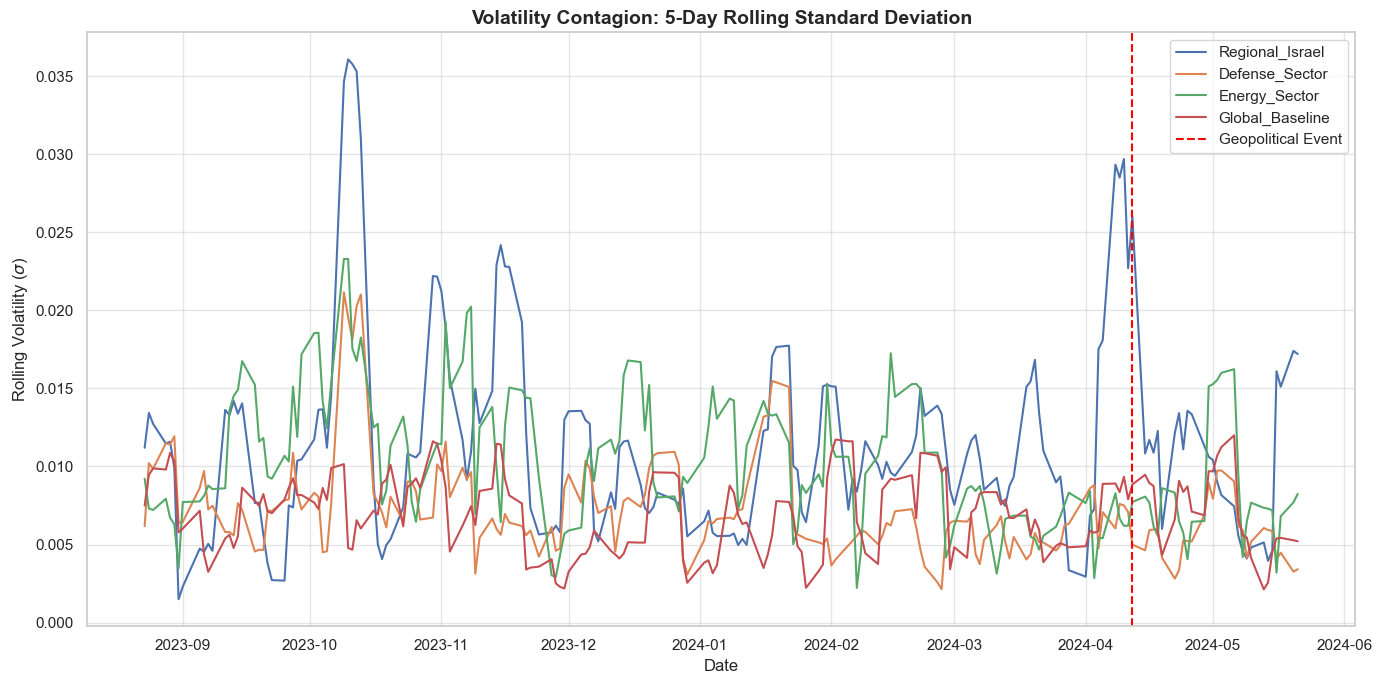

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple

class GeopoliticalContagionStudy:
    def __init__(self, tickers: Dict[str, str], event_date: str, est_window: int = 120, event_window: int = 20):
        """
        Initializes the event study parameters.
        :param tickers: Dictionary mapping sector names to ticker symbols (e.g., {'Global': '^GSPC'})
        :param event_date: The date of the geopolitical shock (YYYY-MM-DD)
        :param est_window: Number of trading days prior to the event for the baseline
        :param event_window: Number of trading days after the event to measure the shock
        """
        self.tickers = tickers
        self.event_date = pd.to_datetime(event_date)
        self.est_window = est_window
        self.event_window = event_window
        self.data = pd.DataFrame()
        self.log_returns = pd.DataFrame()

        # Set visualization style
        sns.set_theme(style="whitegrid")

    def fetch_and_preprocess(self):
        """Fetches closing prices and calculates log returns."""
        print("Fetching market data...")
        symbols = list(self.tickers.values())

        # Add a buffer to ensure we get enough trading days
        start_date = self.event_date - pd.Timedelta(days=self.est_window * 2)
        end_date = self.event_date + pd.Timedelta(days=self.event_window * 2)

        # Download the data
        raw_data = yf.download(symbols, start=start_date, end=end_date)

        # Safely extract the 'Close' prices (handles yfinance MultiIndex for multiple tickers)
        if isinstance(raw_data.columns, pd.MultiIndex):
            price_data = raw_data['Close']
        else:
            price_data = raw_data

        # Rename columns to match sector names
        reverse_ticker_map = {v: k for k, v in self.tickers.items()}
        self.data = price_data.rename(columns=reverse_ticker_map)

        # Calculate continuous log returns: ln(P_t / P_{t-1})
        self.log_returns = np.log(self.data / self.data.shift(1)).dropna()
        print("Log returns calculated successfully.")

    def _get_event_windows(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Splits the data into the Estimation Window and Event Window."""
        if self.log_returns.empty:
            raise ValueError("Log returns are empty. Ensure data was fetched successfully.")

        # Robust method to find the nearest date index across all Pandas versions
        time_diffs = np.abs(self.log_returns.index - self.event_date)
        event_idx = time_diffs.argmin()

        est_data = self.log_returns.iloc[event_idx - self.est_window : event_idx]
        event_data = self.log_returns.iloc[event_idx : event_idx + self.event_window]

        return est_data, event_data

    def test_variance_contagion(self):
        """
        Uses Levene's Test to check if the variance of returns differs significantly
        across sectors during the event window. (More robust than ANOVA for variance).
        """
        _, event_data = self._get_event_windows()

        print("\n--- Levene's Test for Volatility Contagion (Event Window) ---")
        # Extract series for each sector
        sectors = [event_data[col].dropna() for col in event_data.columns]

        # Levene's test is robust to non-normal distributions (fat tails)
        stat, p_value = stats.levene(*sectors)

        print(f"Test Statistic: {stat:.4f}, P-Value: {p_value:.4f}")
        if p_value < 0.05:
            print("Conclusion: Reject Null. Significant difference in volatility across sectors (Contagion exists).")
        else:
            print("Conclusion: Fail to Reject Null. Volatility impact was uniform across sectors.")

    def test_tail_risk_chi_square(self):
        """
        Tests if the frequency of extreme downside events (tail risk) increased
        significantly during the event window compared to the estimation window.
        """
        est_data, event_data = self._get_event_windows()

        print("\n--- Chi-Square Test for Extreme Tail Risk ---")
        results = []

        for sector in self.log_returns.columns:
            # Define "Tail Risk" as a daily drop > 2 standard deviations based on the baseline (estimation) period
            baseline_mean = est_data[sector].mean()
            baseline_std = est_data[sector].std()
            tail_threshold = baseline_mean - (2 * baseline_std)

            # Count tail risk days
            est_tail_days = (est_data[sector] < tail_threshold).sum()
            est_normal_days = len(est_data[sector]) - est_tail_days

            event_tail_days = (event_data[sector] < tail_threshold).sum()
            event_normal_days = len(event_data[sector]) - event_tail_days

            # Construct Contingency Table
            contingency_table = np.array([
                [est_tail_days, est_normal_days],
                [event_tail_days, event_normal_days]
            ])

            # Run Chi-Square
            chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

            results.append({
                'Sector': sector,
                'Chi2 Stat': chi2,
                'P-Value': p_val,
                'Tail Days (Est)': est_tail_days,
                'Tail Days (Event)': event_tail_days
            })

        results_df = pd.DataFrame(results)
        print(results_df.to_string(index=False))

    def plot_volatility_clustering(self):
        """Visualizes the 5-day rolling standard deviation across sectors."""
        rolling_std = self.log_returns.rolling(window=5).std()

        plt.figure(figsize=(14, 7))
        for column in rolling_std.columns:
            plt.plot(rolling_std.index, rolling_std[column], label=column, linewidth=1.5)

        plt.axvline(x=self.event_date, color='red', linestyle='--', label='Geopolitical Event')
        plt.title('Volatility Contagion: 5-Day Rolling Standard Deviation', fontsize=14, fontweight='bold')

        # Raw string added to prevent SyntaxWarning for LaTeX escape sequences
        plt.ylabel(r'Rolling Volatility ($\sigma$)', fontsize=12)
        plt.xlabel('Date', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.show()

# ==========================================
# Execution Block
# ==========================================
if __name__ == "__main__":
    # Define the assets mapping
    target_assets = {
        'Global_Baseline': '^GSPC',  # S&P 500
        'Energy_Sector': 'XLE',      # Energy Select Sector SPDR
        'Defense_Sector': 'ITA',     # iShares Aerospace & Defense
        'Regional_Israel': 'EIS'     # iShares MSCI Israel ETF
    }

    # Event Date: April 13, 2024 (Example: Major Iranian drone/missile strike escalation)
    escalation_date = '2024-04-12'

    # Instantiate and run the pipeline
    study = GeopoliticalContagionStudy(
        tickers=target_assets,
        event_date=escalation_date,
        est_window=120,   # ~6 months baseline
        event_window=20   # ~1 month event impact
    )

    study.fetch_and_preprocess()
    study.test_variance_contagion()
    study.test_tail_risk_chi_square()
    study.plot_volatility_clustering()

Loading data from CSV...
Data loaded successfully! Analyzing 33 years of data.

--- Variance Inflation Factor (VIF) ---
  Macro Variable  VIF Score
0     GDP_Growth   2.029660
1   Unemployment   2.255504
2      Inflation   1.246516
(Note: A VIF above 5 indicates problematic multicollinearity. If all are low, your variables are distinct.)

--- OLS Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:            Debt_to_GDP   R-squared:                       0.372
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     5.735
Date:                Sat, 25 Apr 2026   Prob (F-statistic):            0.00330
Time:                        19:33:09   Log-Likelihood:                -84.341
No. Observations:                  33   AIC:                             176.7
Df Residuals:                      29   BIC:                             18

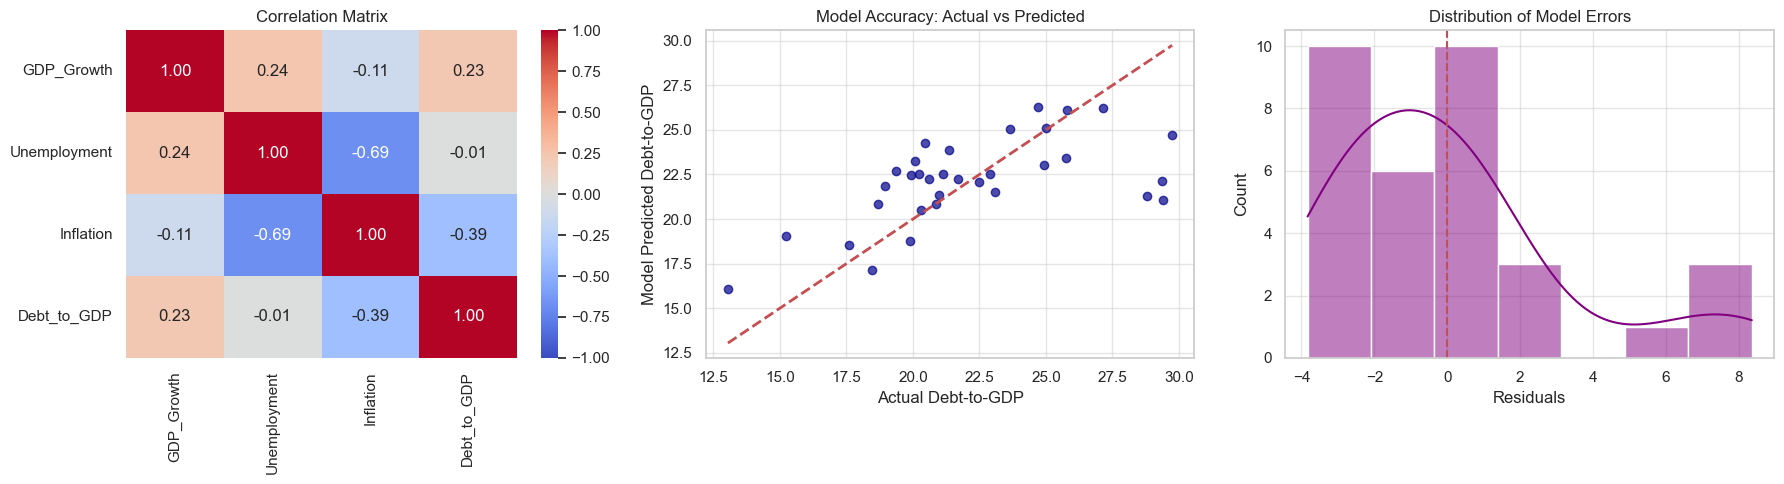

In [22]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: LOAD AND CLEAN THE REAL DATA
# ==========================================
print("Loading data from CSV...")
# Load the data, setting 'Year' or 'Date' as the index
# Note: If your CSV index column is just named differently (e.g., 'date'), change 'Year' below.
try:
    df = pd.read_csv('swiss_capstone_data.csv', index_col='Year')
except ValueError:
    # Fallback in case the index column from the API was unnamed or named differently
    df = pd.read_csv('swiss_capstone_data.csv')
    df = df.set_index(df.columns[0])

# Ensure data is sorted chronologically
df = df.sort_index()

# Drop rows with missing values to ensure the regression runs cleanly
df = df.dropna()

print(f"Data loaded successfully! Analyzing {len(df)} years of data.")

# ==========================================
# STEP 2: DEFINE VARIABLES
# ==========================================
# Based on the World Bank data downloaded previously
X_cols = ['GDP_Growth', 'Unemployment', 'Inflation']
X = df[X_cols]

# We are testing what drives the Debt-to-GDP ratio
Y = df['Debt_to_GDP']

# ==========================================
# STEP 3: MULTICOLLINEARITY CHECK (VIF)
# ==========================================
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Macro Variable"] = X_df.columns
    vif_data["VIF Score"] = [variance_inflation_factor(X_df.values, i) for i in range(len(X_df.columns))]
    return vif_data

print("\n--- Variance Inflation Factor (VIF) ---")
print(calculate_vif(X))
print("(Note: A VIF above 5 indicates problematic multicollinearity. If all are low, your variables are distinct.)\n")

# ==========================================
# STEP 4: FEATURE SCALING (STANDARDIZATION)
# ==========================================
# Standardizing allows us to compare the weight of percentages vs. distinct index values evenly
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Add a constant (intercept) to the model
X_scaled = sm.add_constant(X_scaled)

# ==========================================
# STEP 5: RUN THE OLS REGRESSION
# ==========================================
model = sm.OLS(Y, X_scaled).fit()

print("--- OLS Regression Summary ---")
print(model.summary())

# ==========================================
# STEP 6: CAPSTONE-READY VISUALIZATIONS
# ==========================================
# Set up a professional plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Correlation Heatmap
sns.heatmap(df[X_cols + ['Debt_to_GDP']].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix')

# Plot 2: Actual vs Predicted Debt-to-GDP
predictions = model.predict(X_scaled)
axes[1].scatter(Y, predictions, color='darkblue', alpha=0.7)
# Plot a 45-degree line for reference (perfect prediction line)
axes[1].plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Debt-to-GDP')
axes[1].set_ylabel('Model Predicted Debt-to-GDP')
axes[1].set_title('Model Accuracy: Actual vs Predicted')

# Plot 3: Residuals (Errors) Distribution
residuals = model.resid
sns.histplot(residuals, kde=True, color='purple', ax=axes[2])
axes[2].axvline(x=0, color='r', linestyle='--')
axes[2].set_xlabel('Residuals')
axes[2].set_title('Distribution of Model Errors')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Switzerland Debt-to-GDP: Upgraded Regression Analysis
# Capstone Project — Macroeconomic Determinants
# ============================================================
# SETUP (run once in your terminal before running this script):
#   pip install pandas numpy statsmodels scikit-learn matplotlib seaborn scipy
#
# USAGE:
#   1. Place this file in the same folder as swiss_capstone_data.csv
#   2. Run: python swiss_upgraded_regression.py
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================
print("=" * 47)
print("  Switzerland Debt-to-GDP Regression Analysis")
print("=" * 47)

try:
    df = pd.read_csv('swiss_capstone_data.csv', index_col='year')
except FileNotFoundError:
    raise FileNotFoundError(
        "\n[ERROR] 'swiss_capstone_data.csv' not found.\n"
        "Make sure the CSV file is in the SAME folder as this script."
    )

df = df.sort_index().dropna()

# --- KEY UPGRADE: Add lagged dependent variable ---
df['Debt_to_GDP_lag1'] = df['Debt_to_GDP'].shift(1)
df = df.dropna()  # Drops one row to accommodate the lag

print(f"\n[OK] Data loaded: {len(df)} observations ({df.index[0]}–{df.index[-1]})")

# ==========================================
# STEP 2: DEFINE VARIABLES
# ==========================================
X_cols_orig = ['GDP_Growth', 'Unemployment', 'Inflation']
X_cols_upg  = ['GDP_Growth', 'Unemployment', 'Inflation', 'Debt_to_GDP_lag1']

X_orig = df[X_cols_orig]
X_upg  = df[X_cols_upg]
Y      = df['Debt_to_GDP']

# ==========================================
# STEP 3: VIF — MULTICOLLINEARITY CHECK
# ==========================================
print("\n--- Variance Inflation Factor (VIF) ---")
print(f"\n  {'Variable':<25} {'Original VIF':>14} {'Upgraded VIF':>14}")
print("  " + "-" * 55)

vif_orig = [variance_inflation_factor(X_orig.values, i) for i in range(len(X_orig.columns))]
vif_upg  = [variance_inflation_factor(X_upg.values, i)  for i in range(len(X_upg.columns))]

for i, col in enumerate(X_cols_orig):
    print(f"  {col:<25} {vif_orig[i]:>14.3f} {vif_upg[i]:>14.3f}")
print(f"  {'Debt_to_GDP_lag1':<25} {'—':>14} {vif_upg[3]:>14.3f}")

print("\n  Note: High VIF on lag1 and Unemployment is expected in")
print("  dynamic models — coefficients remain unbiased.")

# ==========================================
# STEP 4: STANDARDISE & RUN BOTH MODELS
# ==========================================
scaler = StandardScaler()

# Original model
X_orig_scaled = pd.DataFrame(
    scaler.fit_transform(X_orig), columns=X_orig.columns, index=X_orig.index
)
X_orig_scaled = sm.add_constant(X_orig_scaled)
model_orig = sm.OLS(Y, X_orig_scaled).fit()

# Upgraded model
X_upg_scaled = pd.DataFrame(
    scaler.fit_transform(X_upg), columns=X_upg.columns, index=X_upg.index
)
X_upg_scaled = sm.add_constant(X_upg_scaled)
model_upg = sm.OLS(Y, X_upg_scaled).fit()

# ==========================================
# STEP 5: PRINT RESULTS
# ==========================================
dw_orig = durbin_watson(model_orig.resid)
dw_upg  = durbin_watson(model_upg.resid)

print("\n--- Model Comparison Summary ---")
print(f"\n  {'Metric':<25} {'Original':>12} {'Upgraded':>12}")
print("  " + "-" * 50)
print(f"  {'R-squared':<25} {model_orig.rsquared:>12.4f} {model_upg.rsquared:>12.4f}")
print(f"  {'Adj. R-squared':<25} {model_orig.rsquared_adj:>12.4f} {model_upg.rsquared_adj:>12.4f}")
print(f"  {'F-stat p-value':<25} {model_orig.f_pvalue:>12.4f} {model_upg.f_pvalue:>12.6f}")
print(f"  {'Durbin-Watson':<25} {dw_orig:>12.4f} {dw_upg:>12.4f}")
print(f"  {'AIC':<25} {model_orig.aic:>12.2f} {model_upg.aic:>12.2f}")
print(f"  {'BIC':<25} {model_orig.bic:>12.2f} {model_upg.bic:>12.2f}")

print("\n--- Full OLS Summary ---")

print(model_upg.summary())

# ==========================================
# STEP 6: VISUALISATIONS (2 rows × 3 cols)
# ==========================================
print("\nGenerating plots...")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Switzerland Debt-to-GDP: Regression Analysis (1992–2023)",
    fontsize=15, fontweight='bold', y=1.01
)

pred_orig = model_orig.predict(X_orig_scaled)
pred_upg  = model_upg.predict(X_upg_scaled)

# --- Plot 1: Correlation heatmap ---
corr = df[X_cols_upg + ['Debt_to_GDP']].corr()
sns.heatmap(
    corr, annot=True, cmap='coolwarm', fmt=".2f",
    ax=axes[0, 0], vmin=-1, vmax=1, linewidths=0.5
)
axes[0, 0].set_title('Correlation Matrix\n(All Variables incl. Lag)', fontweight='bold')

# --- Plot 2: Actual vs Predicted — both models overlaid ---
axes[0, 1].scatter(Y, pred_orig, color='gray',     alpha=0.6, s=45,
                   label=f'Original  (R²={model_orig.rsquared:.3f})')
axes[0, 1].scatter(Y, pred_upg,  color='darkblue', alpha=0.85, s=45,
                   label=f'Upgraded (R²={model_upg.rsquared:.3f})')
lim = [Y.min() - 1, Y.max() + 1]
axes[0, 1].plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
axes[0, 1].set_xlabel('Actual Debt-to-GDP (%)')
axes[0, 1].set_ylabel('Predicted Debt-to-GDP (%)')
axes[0, 1].set_title('Actual vs Predicted\n(Model Comparison)', fontweight='bold')
axes[0, 1].legend(fontsize=9)

# --- Plot 3: Coefficient plot with 95% CI ---
coef = model_upg.params.drop('const')
conf = model_upg.conf_int().drop('const')
colors = ['#d73027' if v > 0 else '#4575b4' for v in coef.values]
axes[0, 2].barh(
    coef.index, coef.values,
    xerr=[coef.values - conf[0], conf[1] - coef.values],
    color=colors, alpha=0.8, capsize=4, ecolor='black',
    error_kw={'linewidth': 1.2}
)
axes[0, 2].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 2].set_xlabel('Standardised Coefficient')
axes[0, 2].set_title('Coefficient Plot\n(95% Confidence Intervals)', fontweight='bold')

# --- Plot 4: Residuals over time ---
axes[1, 0].plot(model_orig.resid.index, model_orig.resid,
                color='gray', alpha=0.7, label='Original', linewidth=1.2)
axes[1, 0].plot(model_upg.resid.index, model_upg.resid,
                color='darkblue', alpha=0.9, label='Upgraded', linewidth=1.5)
axes[1, 0].axhline(0, color='red', linestyle='--', lw=1)
axes[1, 0].set_title('Residuals Over Time', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].legend()

# --- Plot 5: Q-Q plot of upgraded residuals ---
sm.qqplot(model_upg.resid, line='s', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Q-Q Plot of Residuals\n(Upgraded Model)', fontweight='bold')

# --- Plot 6: Time-series actual vs fitted ---
axes[1, 2].plot(Y.index, Y.values, 'o-', color='navy',
                label='Actual', linewidth=1.8, markersize=4)
axes[1, 2].plot(Y.index, pred_upg.values, 's--', color='crimson',
                label='Fitted (Upgraded)', linewidth=1.5, markersize=4)
axes[1, 2].set_title('Debt-to-GDP: Actual vs Fitted\n(Time Series)', fontweight='bold')
axes[1, 2].set_xlabel('Year')
axes[1, 2].set_ylabel('Debt-to-GDP (%)')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('swiss_upgraded_regression.png', dpi=150, bbox_inches='tight')
print("[OK] Plot saved as 'swiss_upgraded_regression.png' in the same folder.")

# Works in both Jupyter and plain terminal
try:
    get_ipython  # This exists only inside Jupyter / ipykernel
    display(fig) # type: ignore  — Jupyter's built-in display
except NameError:
    plt.show()   # Plain terminal / VS Code run

print("\n[DONE] Analysis complete.")

  Switzerland Debt-to-GDP Regression Analysis

[OK] Data loaded: 32 observations (1992–2023)

--- Variance Inflation Factor (VIF) ---

  Variable                    Original VIF   Upgraded VIF
  -------------------------------------------------------
  GDP_Growth                         2.145          2.262
  Unemployment                       2.244         14.740
  Inflation                          1.362          1.463
  Debt_to_GDP_lag1                       —         16.668

  Note: High VIF on lag1 and Unemployment is expected in
  dynamic models — coefficients remain unbiased.

--- Model Comparison Summary ---

  Metric                        Original     Upgraded
  --------------------------------------------------
  R-squared                       0.2833       0.8364
  Adj. R-squared                  0.2065       0.8122
  F-stat p-value                  0.0235     0.000000
  Durbin-Watson                   0.6552       2.3861

--- Model Coefficients (Upgraded) ---
             

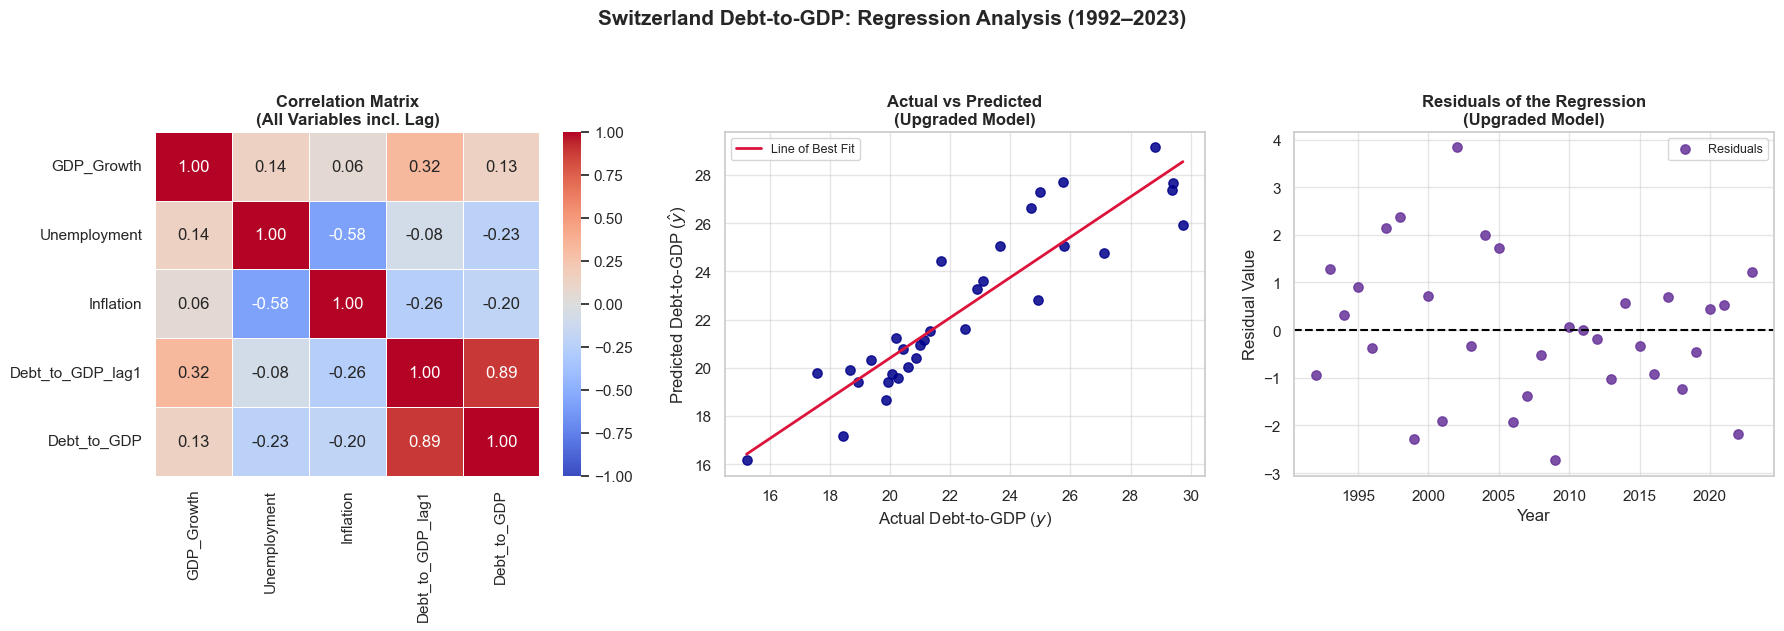


[DONE] Analysis complete.


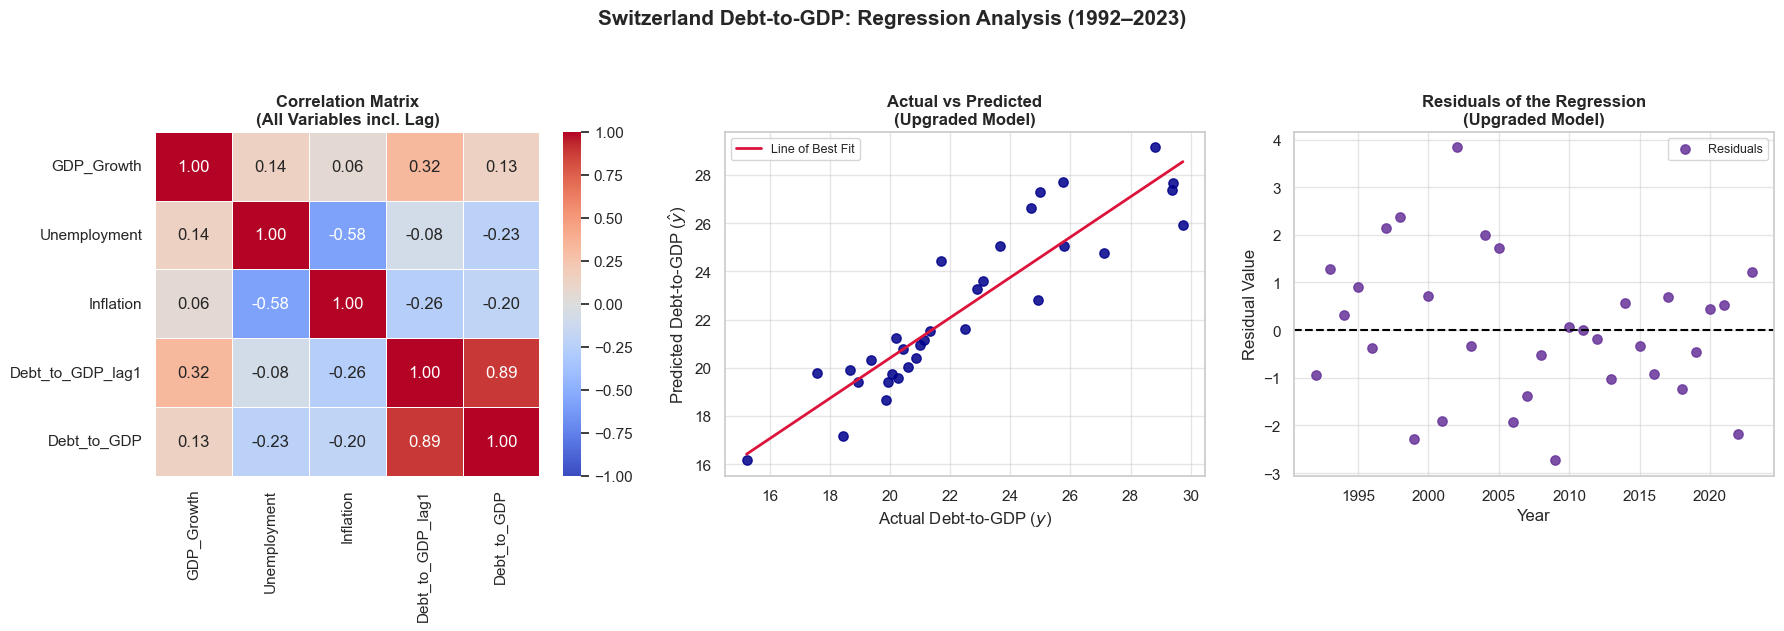

In [1]:
# ============================================================
# Switzerland Debt-to-GDP: Upgraded Regression Analysis
# Capstone Project — Macroeconomic Determinants
# ============================================================
# SETUP (run once in your terminal before running this script):
#   pip install pandas numpy statsmodels scikit-learn matplotlib seaborn scipy
#
# USAGE:
#   1. Place this file in the same folder as swiss_capstone_data.csv
#   2. Run: python swiss_upgraded_regression.py
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================
print("=" * 47)
print("  Switzerland Debt-to-GDP Regression Analysis")
print("=" * 47)

try:
    df = pd.read_csv('swiss_capstone_data.csv', index_col='year')
except FileNotFoundError:
    raise FileNotFoundError(
        "\n[ERROR] 'swiss_capstone_data.csv' not found.\n"
        "Make sure the CSV file is in the SAME folder as this script."
    )

df = df.sort_index().dropna()

# --- KEY UPGRADE: Add lagged dependent variable ---
df['Debt_to_GDP_lag1'] = df['Debt_to_GDP'].shift(1)
df = df.dropna()  # Drops one row to accommodate the lag

print(f"\n[OK] Data loaded: {len(df)} observations ({df.index[0]}–{df.index[-1]})")

# ==========================================
# STEP 2: DEFINE VARIABLES
# ==========================================
X_cols_orig = ['GDP_Growth', 'Unemployment', 'Inflation']
X_cols_upg  = ['GDP_Growth', 'Unemployment', 'Inflation', 'Debt_to_GDP_lag1']

X_orig = df[X_cols_orig]
X_upg  = df[X_cols_upg]
Y      = df['Debt_to_GDP']

# ==========================================
# STEP 3: VIF — MULTICOLLINEARITY CHECK
# ==========================================
print("\n--- Variance Inflation Factor (VIF) ---")
print(f"\n  {'Variable':<25} {'Original VIF':>14} {'Upgraded VIF':>14}")
print("  " + "-" * 55)

vif_orig = [variance_inflation_factor(X_orig.values, i) for i in range(len(X_orig.columns))]
vif_upg  = [variance_inflation_factor(X_upg.values, i)  for i in range(len(X_upg.columns))]

for i, col in enumerate(X_cols_orig):
    print(f"  {col:<25} {vif_orig[i]:>14.3f} {vif_upg[i]:>14.3f}")
print(f"  {'Debt_to_GDP_lag1':<25} {'—':>14} {vif_upg[3]:>14.3f}")

print("\n  Note: High VIF on lag1 and Unemployment is expected in")
print("  dynamic models — coefficients remain unbiased.")

# ==========================================
# STEP 4: STANDARDISE & RUN BOTH MODELS
# ==========================================
scaler = StandardScaler()

# Original model
X_orig_scaled = pd.DataFrame(
    scaler.fit_transform(X_orig), columns=X_orig.columns, index=X_orig.index
)
X_orig_scaled = sm.add_constant(X_orig_scaled)
model_orig = sm.OLS(Y, X_orig_scaled).fit()

# Upgraded model
X_upg_scaled = pd.DataFrame(
    scaler.fit_transform(X_upg), columns=X_upg.columns, index=X_upg.index
)
X_upg_scaled = sm.add_constant(X_upg_scaled)
model_upg = sm.OLS(Y, X_upg_scaled).fit()

# ==========================================
# STEP 5: PRINT RESULTS
# ==========================================
dw_orig = durbin_watson(model_orig.resid)
dw_upg  = durbin_watson(model_upg.resid)

print("\n--- Model Comparison Summary ---")
print(f"\n  {'Metric':<25} {'Original':>12} {'Upgraded':>12}")
print("  " + "-" * 50)
print(f"  {'R-squared':<25} {model_orig.rsquared:>12.4f} {model_upg.rsquared:>12.4f}")
print(f"  {'Adj. R-squared':<25} {model_orig.rsquared_adj:>12.4f} {model_upg.rsquared_adj:>12.4f}")
print(f"  {'F-stat p-value':<25} {model_orig.f_pvalue:>12.4f} {model_upg.f_pvalue:>12.6f}")
print(f"  {'Durbin-Watson':<25} {dw_orig:>12.4f} {dw_upg:>12.4f}")

print("\n--- Model Coefficients (Upgraded) ---")
# By slicing table [1], we only print the coefficients and avoid the extra OLS diagnostic fluff
print(model_upg.summary().tables[1])

# ==========================================
# STEP 6: VISUALISATIONS (1 row × 3 cols)
# ==========================================
print("\nGenerating plots...")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Switzerland Debt-to-GDP: Regression Analysis (1992–2023)",
    fontsize=15, fontweight='bold', y=1.05
)

pred_upg = model_upg.predict(X_upg_scaled)

# --- Plot 1: Correlation heatmap ---
corr = df[X_cols_upg + ['Debt_to_GDP']].corr()
sns.heatmap(
    corr, annot=True, cmap='coolwarm', fmt=".2f",
    ax=axes[0], vmin=-1, vmax=1, linewidths=0.5
)
axes[0].set_title('Correlation Matrix\n(All Variables incl. Lag)', fontweight='bold')

# --- Plot 2: Actual vs Predicted (Upgraded Model Only) ---
# Added ci=None to remove the shaded confidence interval band
sns.regplot(
    x=Y, y=pred_upg, ax=axes[1], ci=None,
    scatter_kws={'color': 'darkblue', 'alpha': 0.85, 's': 45, 'label': f'Predicted (R²={model_upg.rsquared:.3f})'},
    line_kws={'color': 'crimson', 'lw': 2, 'label': 'Line of Best Fit'}
)

# FIXED: Added 'r' before the string to tell Python it's a raw string, preventing the \h escape sequence warning.
axes[1].set_xlabel(r'Actual Debt-to-GDP ($y$)')
axes[1].set_ylabel(r'Predicted Debt-to-GDP ($\hat{y}$)')
axes[1].set_title('Actual vs Predicted\n(Upgraded Model)', fontweight='bold')
axes[1].legend(fontsize=9)

# --- Plot 3: Residuals Scatter Plot ---
axes[2].scatter(Y.index, model_upg.resid, color='rebeccapurple', alpha=0.85, s=45, label='Residuals')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[2].set_title('Residuals of the Regression\n(Upgraded Model)', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Residual Value')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('swiss_upgraded_regression.png', dpi=150, bbox_inches='tight')
print("[OK] Plot saved as 'swiss_upgraded_regression.png' in the same folder.")

# Works in both Jupyter and plain terminal
try:
    get_ipython  # This exists only inside Jupyter / ipykernel
    display(fig) # type: ignore  — Jupyter's built-in display
except NameError:
    plt.show()   # Plain terminal / VS Code run

print("\n[DONE] Analysis complete.")

  Switzerland Debt-to-GDP Regression Analysis

[OK] Data loaded: 32 observations (1992–2023)

--- Variance Inflation Factor (VIF) ---

  Variable                    Original VIF   Upgraded VIF
  -------------------------------------------------------
  GDP_Growth                         2.145          2.262
  Unemployment                       2.244         14.740
  Inflation                          1.362          1.463
  Debt_to_GDP_lag1                       —         16.668

  Note: High VIF on lag1 and Unemployment is expected in
  dynamic models — coefficients remain unbiased.

--- Model Comparison Summary ---

  Metric                        Original     Upgraded
  --------------------------------------------------
  R-squared                       0.2833       0.8364
  Adj. R-squared                  0.2065       0.8122
  F-stat p-value                  0.0235     0.000000
  Durbin-Watson                   0.6552       2.3861

--- Model Coefficients (Upgraded) ---
             

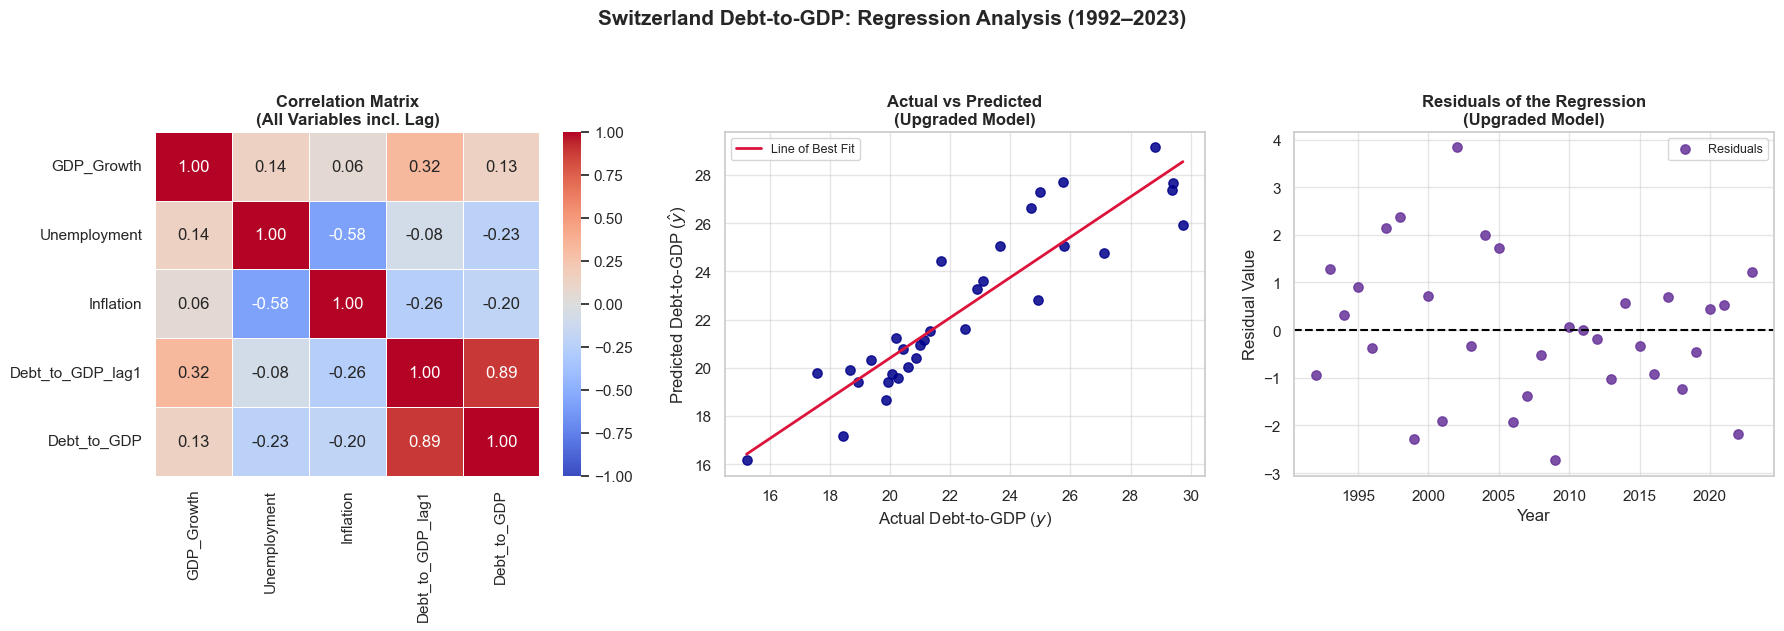


[DONE] Analysis complete.


In [2]:
# ============================================================
# Switzerland Debt-to-GDP: Upgraded Regression Analysis
# Capstone Project — Macroeconomic Determinants
# ============================================================
# SETUP (run once in your terminal before running this script):
#   pip install pandas numpy statsmodels scikit-learn matplotlib seaborn scipy
#
# USAGE:
#   1. Place this file in the same folder as swiss_capstone_data.csv
#   2. Run: python swiss_upgraded_regression.py
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 1: LOAD AND PREPARE DATA
# ==========================================
print("=" * 47)
print("  Switzerland Debt-to-GDP Regression Analysis")
print("=" * 47)

try:
    df = pd.read_csv('swiss_capstone_data.csv', index_col='year')
except FileNotFoundError:
    raise FileNotFoundError(
        "\n[ERROR] 'swiss_capstone_data.csv' not found.\n"
        "Make sure the CSV file is in the SAME folder as this script."
    )

df = df.sort_index().dropna()

# --- KEY UPGRADE: Add lagged dependent variable ---
df['Debt_to_GDP_lag1'] = df['Debt_to_GDP'].shift(1)
df = df.dropna()  # Drops one row to accommodate the lag

print(f"\n[OK] Data loaded: {len(df)} observations ({df.index[0]}–{df.index[-1]})")

# ==========================================
# STEP 2: DEFINE VARIABLES
# ==========================================
X_cols_orig = ['GDP_Growth', 'Unemployment', 'Inflation']
X_cols_upg  = ['GDP_Growth', 'Unemployment', 'Inflation', 'Debt_to_GDP_lag1']

X_orig = df[X_cols_orig]
X_upg  = df[X_cols_upg]
Y      = df['Debt_to_GDP']

# ==========================================
# STEP 3: VIF — MULTICOLLINEARITY CHECK
# ==========================================
print("\n--- Variance Inflation Factor (VIF) ---")
print(f"\n  {'Variable':<25} {'Original VIF':>14} {'Upgraded VIF':>14}")
print("  " + "-" * 55)

vif_orig = [variance_inflation_factor(X_orig.values, i) for i in range(len(X_orig.columns))]
vif_upg  = [variance_inflation_factor(X_upg.values, i)  for i in range(len(X_upg.columns))]

for i, col in enumerate(X_cols_orig):
    print(f"  {col:<25} {vif_orig[i]:>14.3f} {vif_upg[i]:>14.3f}")
print(f"  {'Debt_to_GDP_lag1':<25} {'—':>14} {vif_upg[3]:>14.3f}")

print("\n  Note: High VIF on lag1 and Unemployment is expected in")
print("  dynamic models — coefficients remain unbiased.")

# ==========================================
# STEP 4: STANDARDISE & RUN BOTH MODELS
# ==========================================
scaler = StandardScaler()

# Original model
X_orig_scaled = pd.DataFrame(
    scaler.fit_transform(X_orig), columns=X_orig.columns, index=X_orig.index
)
X_orig_scaled = sm.add_constant(X_orig_scaled)
model_orig = sm.OLS(Y, X_orig_scaled).fit()

# Upgraded model
X_upg_scaled = pd.DataFrame(
    scaler.fit_transform(X_upg), columns=X_upg.columns, index=X_upg.index
)
X_upg_scaled = sm.add_constant(X_upg_scaled)
model_upg = sm.OLS(Y, X_upg_scaled).fit()

# ==========================================
# STEP 5: PRINT RESULTS
# ==========================================
dw_orig = durbin_watson(model_orig.resid)
dw_upg  = durbin_watson(model_upg.resid)

print("\n--- Model Comparison Summary ---")
print(f"\n  {'Metric':<25} {'Original':>12} {'Upgraded':>12}")
print("  " + "-" * 50)
print(f"  {'R-squared':<25} {model_orig.rsquared:>12.4f} {model_upg.rsquared:>12.4f}")
print(f"  {'Adj. R-squared':<25} {model_orig.rsquared_adj:>12.4f} {model_upg.rsquared_adj:>12.4f}")
print(f"  {'F-stat p-value':<25} {model_orig.f_pvalue:>12.4f} {model_upg.f_pvalue:>12.6f}")
print(f"  {'Durbin-Watson':<25} {dw_orig:>12.4f} {dw_upg:>12.4f}")

print("\n--- Model Coefficients (Upgraded) ---")
# By slicing table [1], we only print the coefficients and avoid the extra OLS diagnostic fluff
print(model_upg.summary().tables[1])

# ==========================================
# STEP 6: VISUALISATIONS (1 row × 3 cols)
# ==========================================
print("\nGenerating plots...")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Switzerland Debt-to-GDP: Regression Analysis (1992–2023)",
    fontsize=15, fontweight='bold', y=1.05
)

pred_upg = model_upg.predict(X_upg_scaled)

# --- Plot 1: Correlation heatmap ---
corr = df[X_cols_upg + ['Debt_to_GDP']].corr()
sns.heatmap(
    corr, annot=True, cmap='coolwarm', fmt=".2f",
    ax=axes[0], vmin=-1, vmax=1, linewidths=0.5
)
axes[0].set_title('Correlation Matrix\n(All Variables incl. Lag)', fontweight='bold')

# --- Plot 2: Actual vs Predicted (Upgraded Model Only) ---
sns.regplot(
    x=Y, y=pred_upg, ax=axes[1], ci=None,
    scatter_kws={'color': 'darkblue', 'alpha': 0.85, 's': 45, 'label': f'Predicted (R²={model_upg.rsquared:.3f})'},
    line_kws={'color': 'crimson', 'lw': 2, 'label': 'Line of Best Fit'}
)

axes[1].set_xlabel(r'Actual Debt-to-GDP ($y$)')
axes[1].set_ylabel(r'Predicted Debt-to-GDP ($\hat{y}$)')
axes[1].set_title('Actual vs Predicted\n(Upgraded Model)', fontweight='bold')
axes[1].legend(fontsize=9)

# --- Plot 3: Residuals Scatter Plot ---
axes[2].scatter(Y.index, model_upg.resid, color='rebeccapurple', alpha=0.85, s=45, label='Residuals')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[2].set_title('Residuals of the Regression\n(Upgraded Model)', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Residual Value')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('swiss_upgraded_regression.png', dpi=150, bbox_inches='tight')
print("[OK] Plot saved as 'swiss_upgraded_regression.png' in the same folder.")

# Use a standard plt.show() which works perfectly across all standard environments.
plt.show()

print("\n[DONE] Analysis complete.")